In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

devices = tf.config.list_physical_devices()
device = devices[1]
print(tf.config.experimental.get_device_details(device))

2026-01-17 23:09:12.468480: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-17 23:09:12.507449: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-17 23:09:13.470688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


{'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3060'}


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [4]:
print(x_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


In [5]:
labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [6]:
labels[y_train[0]]

'Ankle boot'

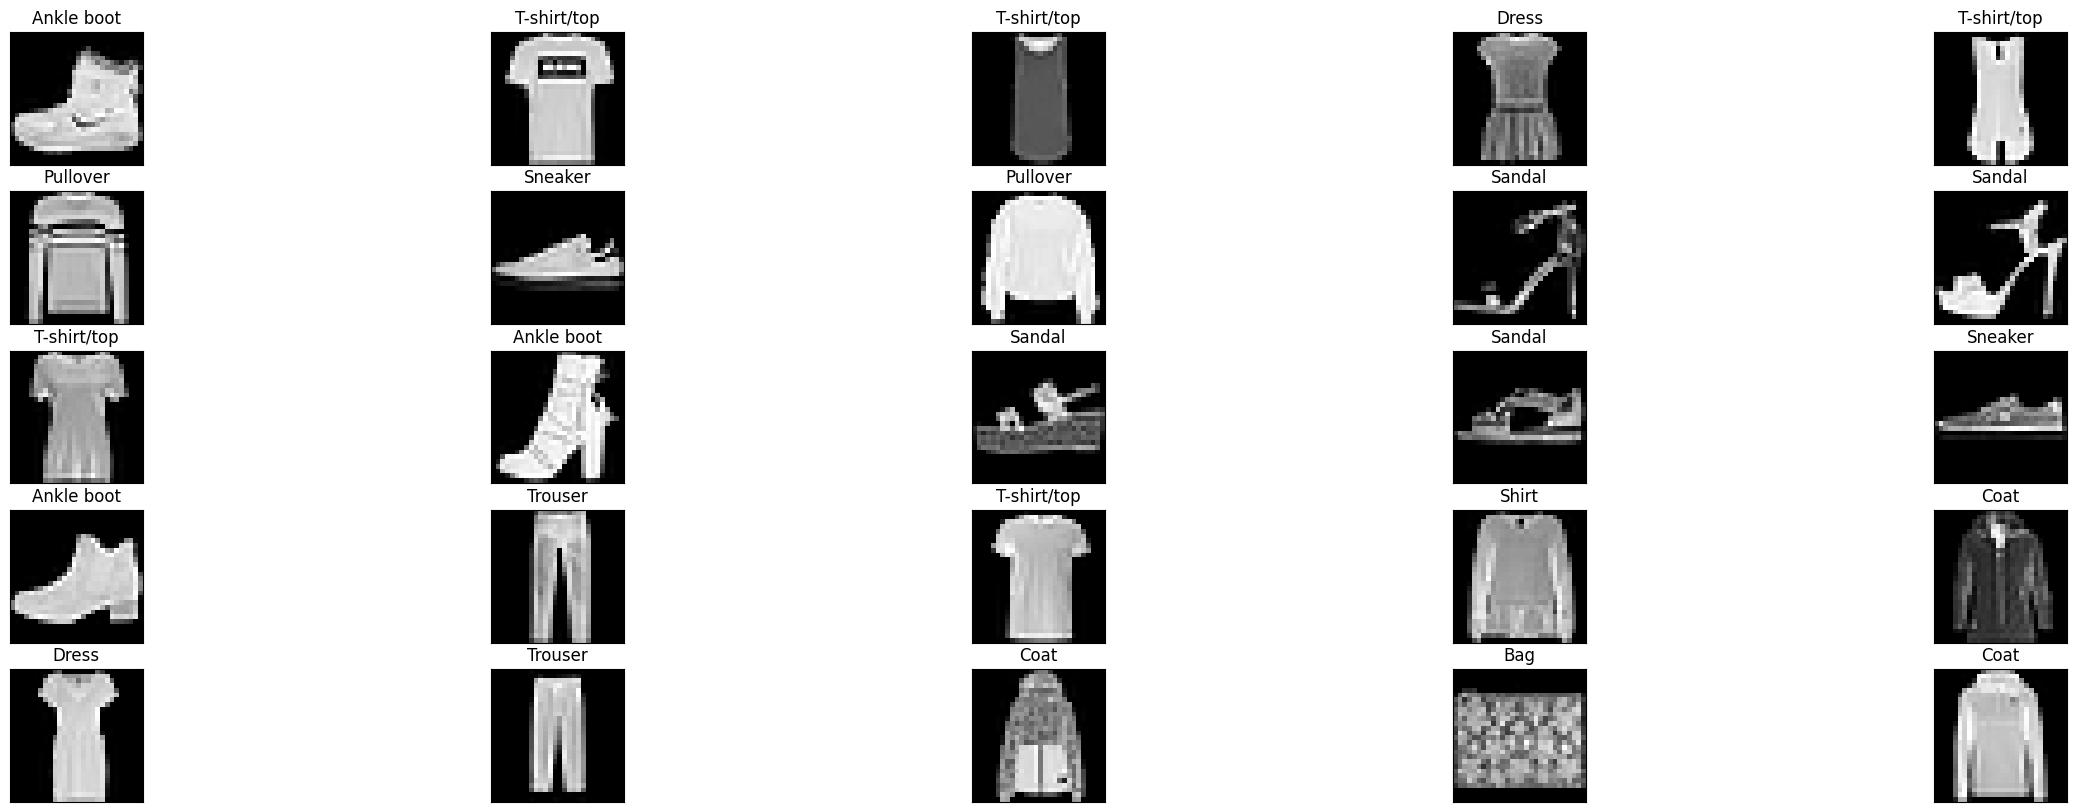

In [7]:
fig, ax = plt.subplots(5,5, figsize=(30,10))
for i in range(25):
    axc = ax[i//5, i%5]
    axc.imshow(x_train[i], cmap="gray")
    axc.set_title(f"{labels[y_train[i]]}")
    axc.set_xticks([])
    axc.set_yticks([])

In [8]:
# Standard function to print loss 

def plot_loss_curves(history):
    plt.clf()
    history_dict = history.history
    loss_values = history_dict["loss"]
    validation_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, loss_values, "bo", label="Training Loss")
    plt.plot(epochs, validation_loss_values, "b", label="Validation Loss")
    plt.title("Training and validation loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.show()
    
def plot_acc_curves(history):
    plt.clf()
    history_dict = history.history
    acc = history_dict["accuracy"]
    validation_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training accuracy")
    plt.plot(epochs, validation_acc, "b", label="validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
    
    

In [9]:
# data normalization

x_train = x_train / 255.0 
x_test = x_test / 255.0 

In [10]:
x_train.shape

(60000, 28, 28)

CNNs expect 3-channels, so increasing the last dimension

In [11]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

x_train.shape

(60000, 28, 28, 1)

## Model

In [12]:
# Input layer
input = keras.Input(shape=x_train.shape[1:])

#CNN block - 1
x = keras.layers.Conv2D(
    32,                 # Number of filters
    kernel_size=(2,2),  # the shape of each filter
    activation="relu",  # ReLU activation 
    name="Conv_1",      # name of layer, for model view
)(input)                # input to this layer

# Pooling 
x = keras.layers.MaxPool2D()(x)

#CNN block - 2
x = keras.layers.Conv2D(
    32, 
    kernel_size = (2,2),
    activation = "relu",
    name = "Conv_2"
)(x)

# Pooling -2 
x = keras.layers.MaxPool2D()(x)

# Flatten leyer
x = keras.layers.Flatten()(x)

# dense layer
x = keras.layers.Dense(256, activation="relu")(x)

# output softmax layer
output = keras.layers.Dense(10, activation="softmax")(x)

model = keras.Model(input, output)
model.summary()

I0000 00:00:1768671555.264315  440141 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10247 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,026 (1.15 MB)

 Trainable params: 302,026 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

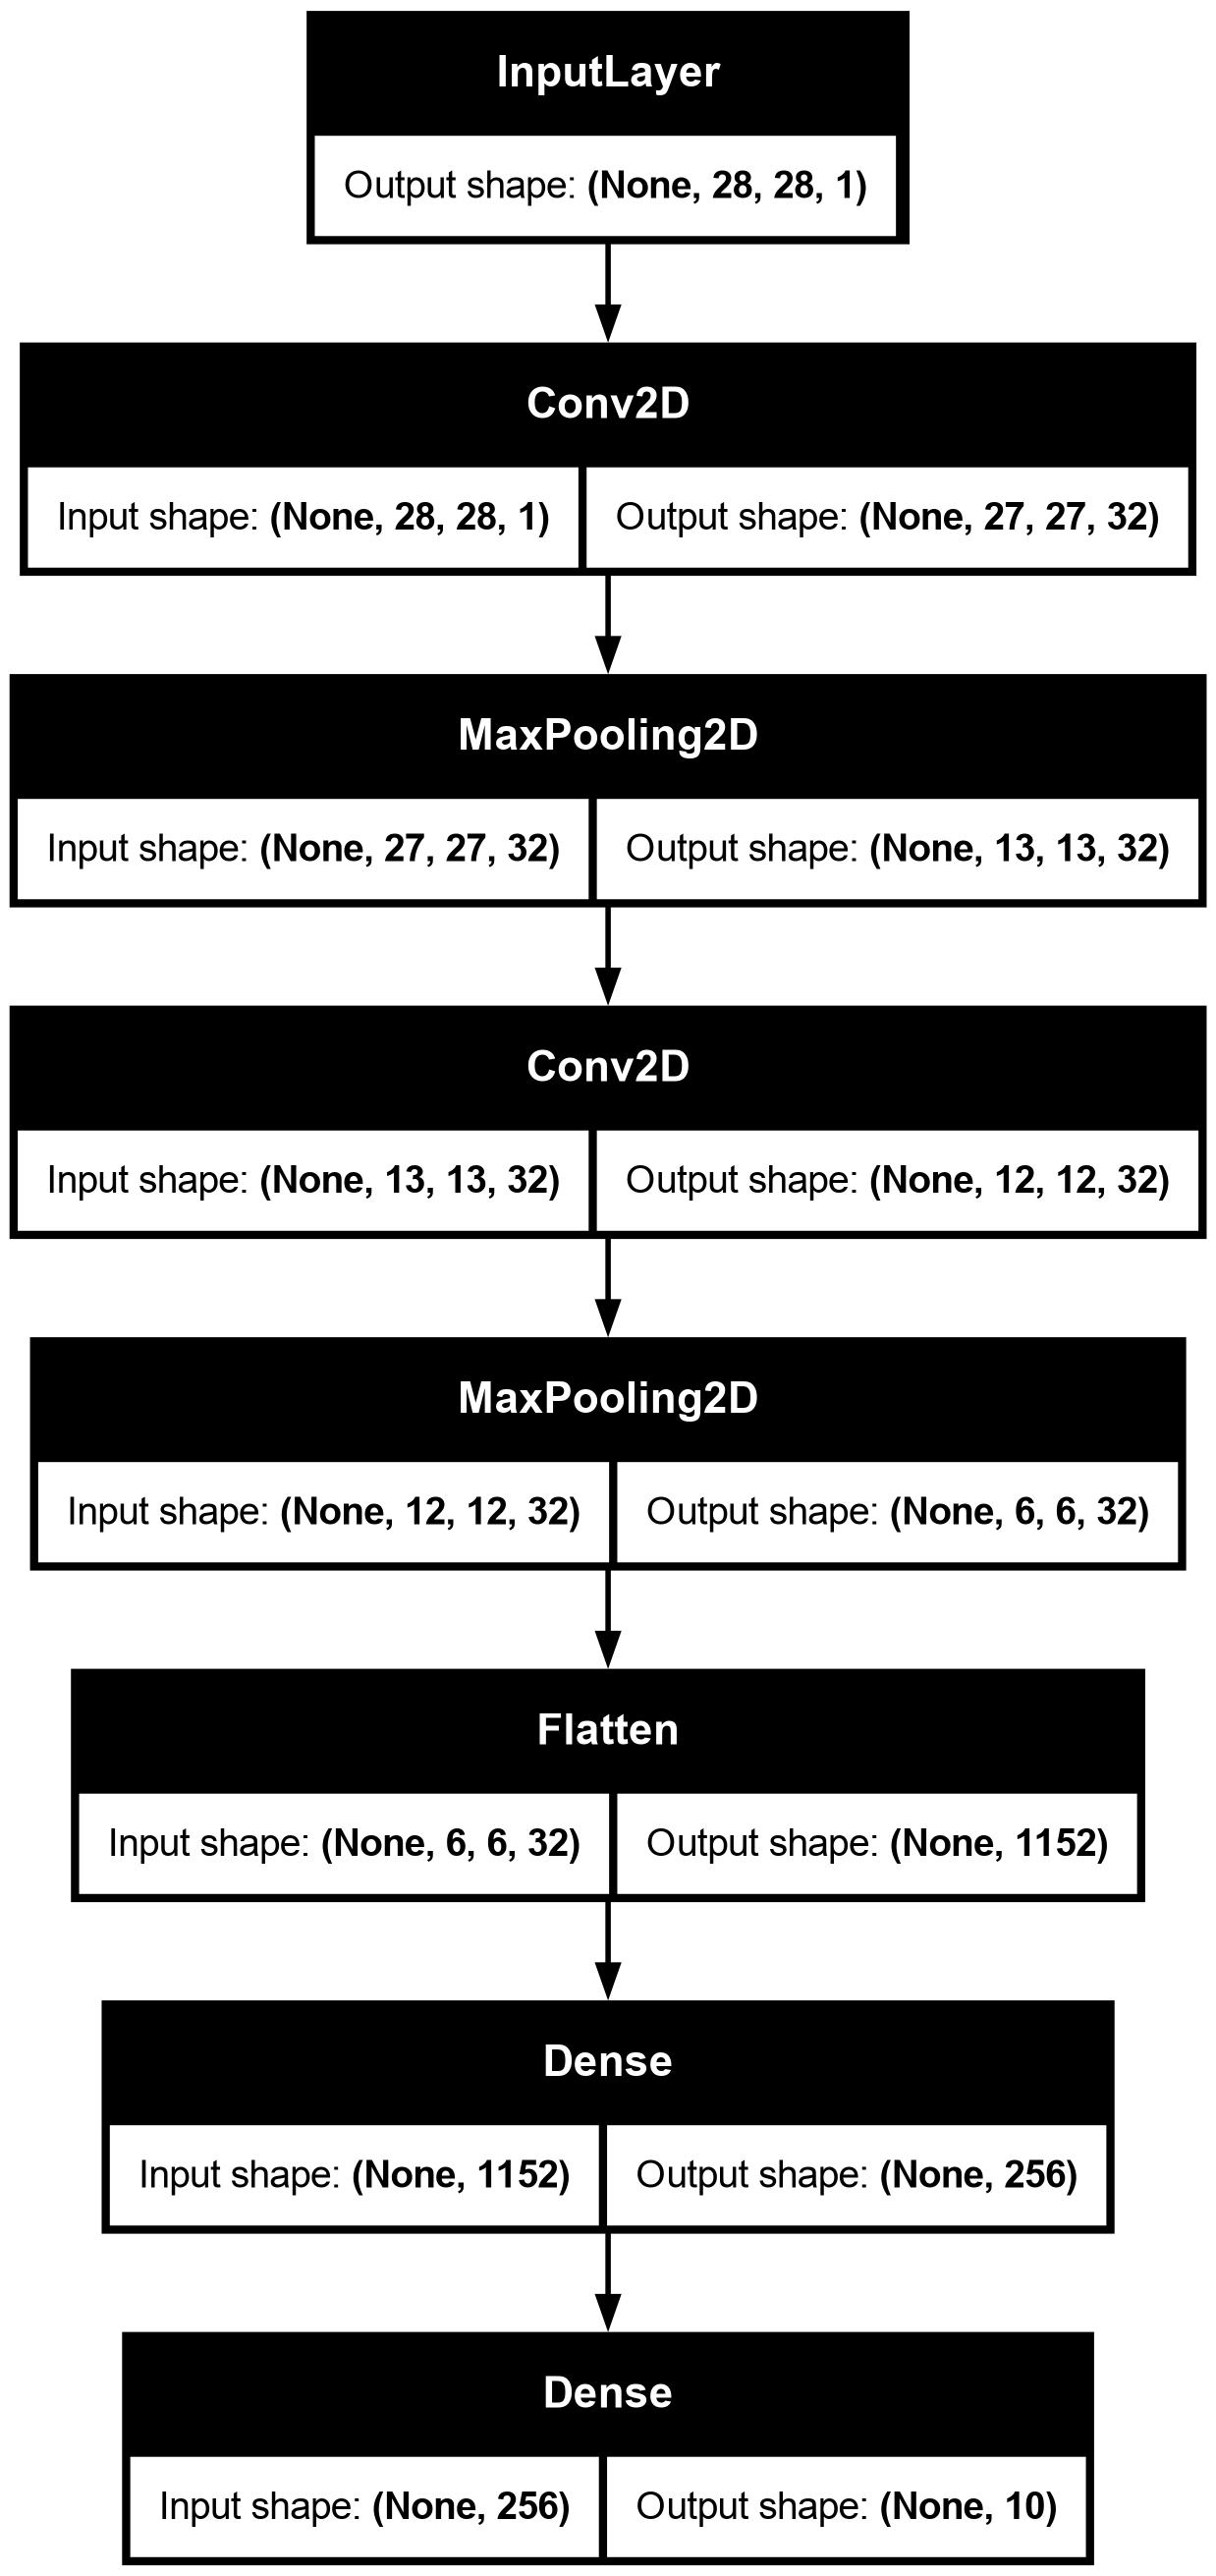

In [13]:
keras.utils.plot_model(model, show_shapes=True)

## Model train and run

In [14]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics= ["accuracy"],
)

In [15]:
history = model.fit(
    x_train,
    y_train,
    batch_size = 64,
    epochs = 10,
    validation_split = 0.2
)

Epoch 1/10


2026-01-17 23:09:16.741825: I external/local_xla/xla/service/service.cc:163] XLA service 0x70a62c004020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-17 23:09:16.741838: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-17 23:09:16.757586: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-17 23:09:16.866534: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


117/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5661 - loss: 1.2722

I0000 00:00:1768671558.586554  440293 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


731/750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7465 - loss: 0.7182

2026-01-17 23:09:20.411890: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_93', 16 bytes spill stores, 16 bytes spill loads



750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8191 - loss: 0.5045 - val_accuracy: 0.8656 - val_loss: 0.3747
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8799 - loss: 0.3349 - val_accuracy: 0.8763 - val_loss: 0.3407
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.2889 - val_accuracy: 0.8940 - val_loss: 0.2920
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9033 - loss: 0.2601 - val_accuracy: 0.9003 - val_loss: 0.2717
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9134 - loss: 0.2348 - val_accuracy: 0.9070 - val_loss: 0.2572
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9205 - loss: 0.2142 - val_accuracy: 0.9047 - val_loss: 0.2627
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9269 - loss: 0.1967 - val_accuracy: 0.9112 - val_loss: 0.2502
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9329 - loss: 0.1789 - val_accuracy: 0.9103 - val_

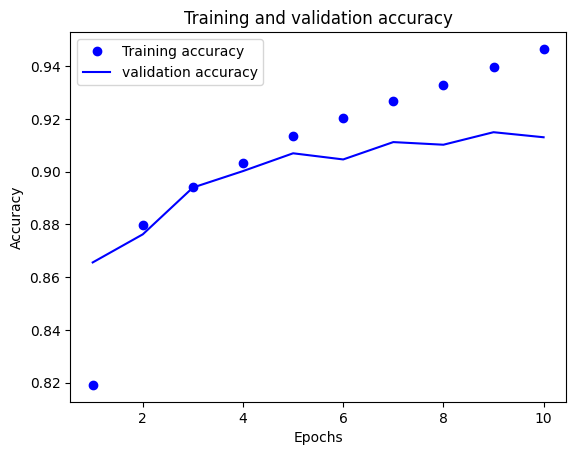

In [16]:
plot_acc_curves(history=history)

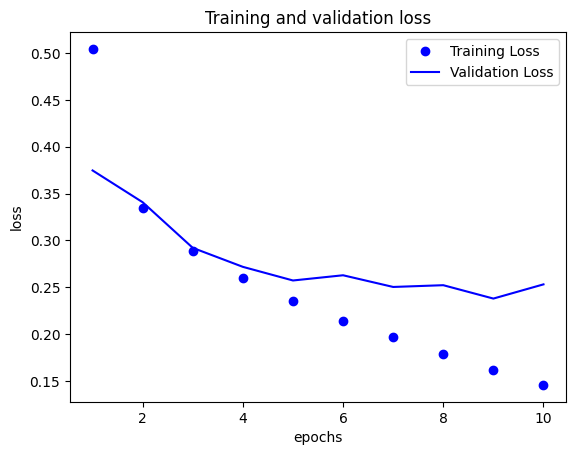

In [17]:
plot_loss_curves(history=history)

In [18]:
score = model.evaluate(x_test, y_test)
print("test accuracy : ", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9058 - loss: 0.2703
test accuracy :  0.9057999849319458
